Instalasi dependensi OCR

In [ ]:
!apt-get update
!apt-get install tesseract-ocr
!pip install pytesseract opencv-python matplotlib

Get:1 http://security.ubuntu.com/ubuntu noble-security InRelease [126 kB]
Hit:2 https://cli.github.com/packages stable InRelease
Get:3 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ InRelease [3,631 B]
Get:4 https://r2u.stat.illinois.edu/ubuntu noble InRelease [9,161 B]
Hit:5 http://archive.ubuntu.com/ubuntu noble InRelease
Get:6 http://archive.ubuntu.com/ubuntu noble-updates InRelease [126 kB]
Get:7 https://cloud.r-project.org/bin/linux/ubuntu noble-cran40/ Packages [73.2 kB]
Hit:8 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu noble InRelease
Get:9 https://r2u.stat.illinois.edu/ubuntu noble/main amd64 Packages [3,012 kB]
Get:10 http://security.ubuntu.com/ubuntu noble-security/main amd64 Packages [1,245 kB]
Get:11 http://archive.ubuntu.com/ubuntu noble-backports InRelease [126 kB]
Get:12 https://r2u.stat.illinois.edu/ubuntu noble/main all Packages [10.2 MB]
Get:13 http://security.ubuntu.com/ubuntu noble-security/universe amd64 Packages [1,533 kB]
Get:14 http://arch

Import Library Yang Dibutuhkan

In [ ]:
import cv2
import numpy as np
import pytesseract
import matplotlib.pyplot as plt
import difflib
from google.colab import files

Fungsi untuk menghitung akurasi

In [ ]:
def calculate_accuracy(gt, test):
    if len(gt) == 0:
        return 0, 0.0

    matcher = difflib.SequenceMatcher(None, gt, test)
    match_chars = sum([m.size for m in matcher.get_matching_blocks()])
    accuracy = (match_chars / len(gt)) * 100

    return match_chars, accuracy

print("Fungsi hitung akurasi siap digunakan.")

Fungsi hitung akurasi siap digunakan.


Upload & baca gambar dan mengubah nya ke Grayscale

In [ ]:
print("Silakan upload file citra ijazah:")
uploaded = files.upload()

filename = list(uploaded.keys())[0]

# Membaca gambar dan mengubah ke Grayscale
img_bgr = cv2.imread(filename)
img_gray = cv2.cvtColor(img_bgr, cv2.COLOR_BGR2GRAY)

# Rotasi 90 derajat searah jarum jam agar teks tidak terbaca vertikal
img_gray = cv2.rotate(img_gray, cv2.ROTATE_90_CLOCKWISE)

print(f"File '{filename}' berhasil diproses (Grayscale & Rotasi).")

Silakan upload file citra ijazah:


Saving 04_HighNoise.jpg to 04_HighNoise.jpg
File '04_HighNoise.jpg' berhasil diproses (Grayscale & Rotasi).


Pemrosessan Filter

In [ ]:
height, width = img_gray.shape
img_cropped = img_gray[height//6 : height, 2 : width]
processed_images = {}

# 1. Original
processed_images = {}
processed_images["Original"] = img_cropped.copy()

# 2. Mean Filter
processed_images["Mean Filter"] = cv2.blur(img_cropped, (5, 5))

# 3. Median Filter
processed_images["Median Filter"] = cv2.medianBlur(img_cropped, 5)

# 4. Gaussian Filter
processed_images["Gaussian Filter"] = cv2.GaussianBlur(img_cropped, (5, 5), 0)

#Sharpening

kernel_sharp = np.array([[0, -1, 0],
                         [-1, 5, -1],
                         [0, -1, 0]])
processed_images["Sharpening"] = cv2.filter2D(img_cropped, -1, kernel_sharp)

print("Gambar berhasil dipotong (crop) dan semua filter diaplikasikan!")

Gambar berhasil dipotong (crop) dan semua filter diaplikasikan!


OCR Processing

In [ ]:
# Teks kunci yang menjadi tolok ukur akurasi (Disesuaikan dengan potongan gambar)
ground_truth = "Nomor ijazah: 571012022000056"
total_gt_chars = len(ground_truth)

ocr_results = {}
print("Mulai mengekstrak teks dengan OCR...\n")

for name, img in processed_images.items():
    # Proses OCR
    text = pytesseract.image_to_string(img).strip()

    # Membersihkan jarak spasi/enter berlebih
    text_clean = " ".join(text.split())

    # Hitung akurasi
    match_chars, acc = calculate_accuracy(ground_truth, text_clean)

    ocr_results[name] = {
        "text": text_clean if text_clean != "" else "[Tidak ada teks terdeteksi]",
        "match_chars": match_chars,
        "accuracy": acc
    }
    print(f"OCR untuk '{name}' selesai.")

print("\nProses OCR selesai seluruhnya.")

Mulai mengekstrak teks dengan OCR...

OCR untuk 'Original' selesai.
OCR untuk 'Mean Filter' selesai.
OCR untuk 'Median Filter' selesai.
OCR untuk 'Gaussian Filter' selesai.
OCR untuk 'Sharpening' selesai.

Proses OCR selesai seluruhnya.


Output dan Visualisasi

Metode          | Hasil OCR (Cuplikan 30 Karakter)    | Karakter Benar  | Akurasi   
Original        | Nomor tyazah: 571012022000056       | 27 dari 29      | 93.10%
Mean Filter     | Nomor ijazah: 571012022000056       | 29 dari 29      | 100.00%
Median Filter   | Nomor ijazah: 571012022000056       | 29 dari 29      | 100.00%
Gaussian Filter | Nomor tjazah: 571012022000056       | 28 dari 29      | 96.55%
Sharpening      | Nomor yazah: 571012022000056        | 27 dari 29      | 93.10%


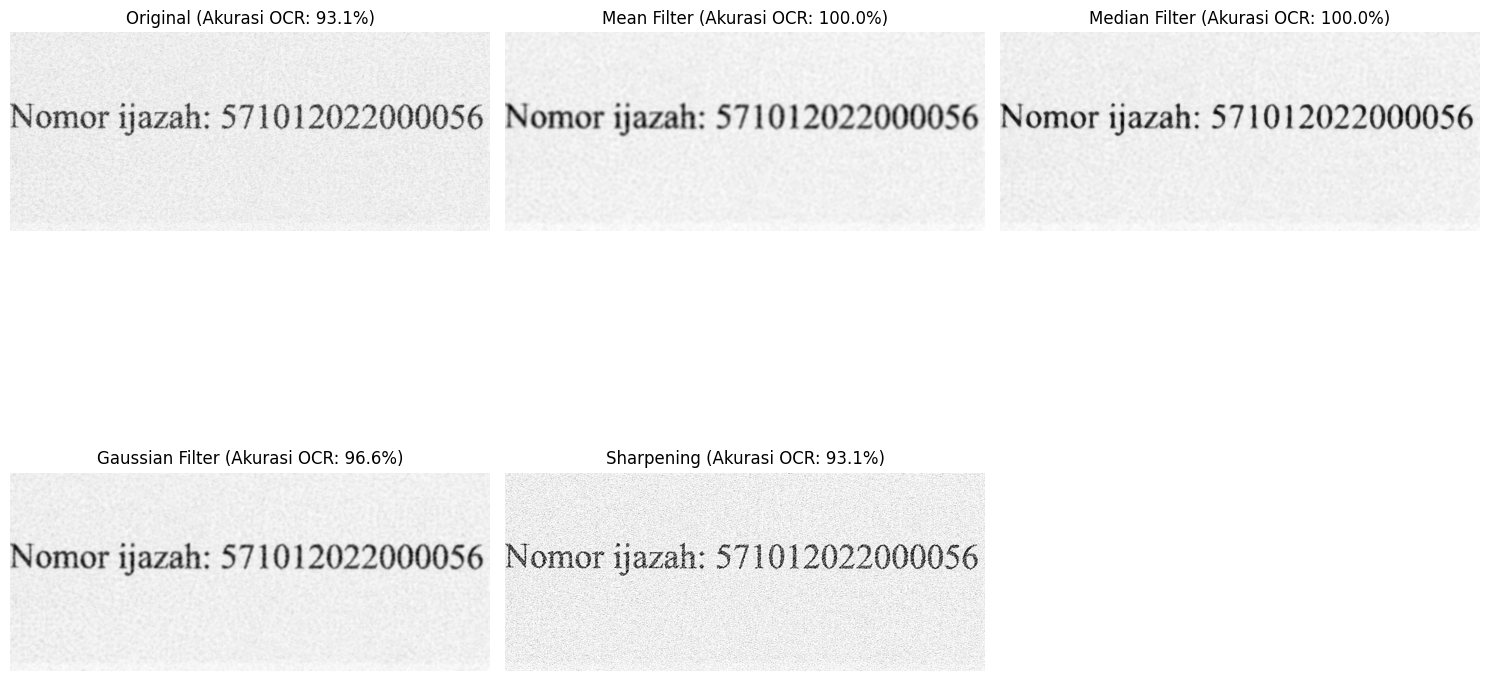

In [ ]:
# --- TABEL HASIL ---
print("="*95)
print(f"{'Metode':<15} | {'Hasil OCR (Cuplikan 30 Karakter)':<35} | {'Karakter Benar':<15} | {'Akurasi':<10}")
print("="*95)

for name, result in ocr_results.items():
    snippet = result["text"][:30] + "..." if len(result["text"]) > 30 else result["text"]
    char_info = f"{result['match_chars']} dari {total_gt_chars}"
    print(f"{name:<15} | {snippet:<35} | {char_info:<15} | {result['accuracy']:.2f}%")
print("="*95)

# --- VISUALISASI ---
plt.figure(figsize=(15, 10))

for i, (name, img) in enumerate(processed_images.items()):
    plt.subplot(2, 3, i+1)
    plt.imshow(img, cmap='gray')
    plt.title(f"{name} (Akurasi OCR: {ocr_results[name]['accuracy']:.1f}%)")
    plt.axis('off')

plt.tight_layout()
plt.show()